In [ ]:
# ── Cell 1 : Dependencies ────────────────────────────────────────────────────
!pip install pennylane pennylane-lightning-gpu umap-learn scipy -q

In [ ]:
# ── Cell 2 : Imports & Global Configuration ──────────────────────────────────
import os
import sys
import warnings
import hashlib
import time
import tracemalloc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from scipy.stats import wilcoxon, pearsonr, spearmanr
from joblib import dump, load

import pennylane as qml

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    warnings.warn("umap-learn not found — UMAP visualization will be skipped.")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Dataset path — override via environment variable DATASET_PATH ─────────────
DATASET_PATH = os.environ.get(
    'DATASET_PATH',
    '/dataset_encoded_normalized1.csv'
)

# ── Quantum circuit hyperparameters ───────────────────────────────────────────
N_LAYERS      = 2          # default
ENTANGLEMENT  = 'circular' # default
DE_MAXITER    = 20
DE_POPSZ      = 10
N_SPLITS_CV   = 5

# ── Cache ─────────────────────────────────────────────────────────────────────
CACHE_DIR = 'cache_quantum_RF_gdsc_5000'
os.makedirs(CACHE_DIR, exist_ok=True)

WEIGHTS_FILE         = os.path.join(CACHE_DIR, 'best_weights.npy')
MODEL_CLASSICAL_FILE = os.path.join(CACHE_DIR, 'rf_classical.joblib')
MODEL_HYBRID_FILE    = os.path.join(CACHE_DIR, 'rf_hybrid.joblib')

FIGDIR = os.path.join(CACHE_DIR, 'figures')
os.makedirs(FIGDIR, exist_ok=True)

print(f'PennyLane version : {qml.version()}')
print(f'Python            : {sys.version.split()[0]}')
print(f'NumPy             : {np.__version__}')
print(f'Dataset path      : {DATASET_PATH}')
print(f'Cache directory   : {os.path.abspath(CACHE_DIR)}')

/home/host1-vm4/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PennyLane version : 0.44.1
Python            : 3.13.11
NumPy             : 2.4.1
Dataset path      : /home/host1-vm4/Downloads/dataset_encoded_normalized1.csv
Cache directory   : /home/host1-vm4/cache_quantum_RF_gdsc_5000


In [ ]:
# ── Cell 3 : Data Loading & Strict 3-Way Split (70 / 15 / 15) ────────────────
#
# Split strategy:
#   X_train (70%) — DE weight optimization + final RF training
#   X_val   (15%) — DE objective evaluation ONLY (never touches final model)
#   X_test  (15%) — final holdout, touched ONCE at the very end
#
# FIX: quantum features are scaled to [-π, π] before angular encoding
# so that RX(x[i]) is meaningful across the full Bloch sphere rotation range.

assert os.path.exists(DATASET_PATH), (
    f'Dataset not found at "{DATASET_PATH}". '
    f'Set the DATASET_PATH environment variable or update the path above.'
)

df = pd.read_csv(DATASET_PATH)
assert 'LN_IC50' in df.columns, "Target column 'LN_IC50' not found in dataset."

X_raw = df.drop(columns=['LN_IC50']).values.astype(np.float64)
Y     = df['LN_IC50'].values.astype(np.float64)

N_FEATURES = X_raw.shape[1]
n_qubits   = N_FEATURES   # 12 qubits for 12 features — no PCA

# Dataset hash for cache versioning
HASH = hashlib.md5(X_raw.data.tobytes()).hexdigest()[:8]

print(f'Dataset  : {X_raw.shape[0]} samples × {N_FEATURES} features')
print(f'Target   : LN_IC50  mean={Y.mean():.3f}  std={Y.std():.3f}  '
      f'min={Y.min():.3f}  max={Y.max():.3f}')
print(f'Hash     : {HASH}')

# ── FIX: scale features to [-π, π] for quantum encoding ──────────────────────
# Scaler fitted on X_train only — applied to val and test to avoid leakage.
X_tr_raw, X_temp, Y_train, Y_temp = train_test_split(
    X_raw, Y, test_size=0.30, random_state=SEED, shuffle=True
)
X_val_raw, X_test_raw, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.50, random_state=SEED
)

scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train = scaler.fit_transform(X_tr_raw)   # fit on train only
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

print(f'\nSplit — Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print('Features scaled to [-π, π] for angular encoding (scaler fitted on X_train only).')
print('X_test will be touched ONCE at the final evaluation cell.')

X_TRAIN_Q_FILE = os.path.join(CACHE_DIR, f'X_train_quantum_{HASH}.npy')
X_VAL_Q_FILE   = os.path.join(CACHE_DIR, f'X_val_quantum_{HASH}.npy')
X_TEST_Q_FILE  = os.path.join(CACHE_DIR, f'X_test_quantum_{HASH}.npy')

Dataset  : 13106 samples × 12 features
Target   : LN_IC50  mean=0.538  std=0.134  min=0.000  max=1.000
Hash     : 8f057170

Split — Train: 9174  Val: 1966  Test: 1966
Features scaled to [-π, π] for angular encoding (scaler fitted on X_train only).
X_test will be touched ONCE at the final evaluation cell.


In [ ]:
# ── Cell 4 : Quantum Device Initialization ────────────────────────────────────

try:
    dev_gpu = qml.device('lightning.gpu', wires=n_qubits)
    DEVICE_LABEL = 'lightning.gpu'
    print(f'GPU device ready : lightning.gpu | {n_qubits} qubits')
except Exception as e:
    warnings.warn(
        f'GPU device unavailable ({e}). Falling back to lightning.qubit (CPU). '
        f'GPU speedup benchmark will compare lightning.qubit vs default.qubit.',
        RuntimeWarning
    )
    dev_gpu = qml.device('lightning.qubit', wires=n_qubits)
    DEVICE_LABEL = 'lightning.qubit (CPU fallback)'

dev_cpu = qml.device('default.qubit', wires=n_qubits)

print(f'Active device     : {DEVICE_LABEL}')
print(f'Benchmark device  : default.qubit (CPU reference)')

GPU device ready : lightning.gpu | 12 qubits
Active device     : lightning.gpu
Benchmark device  : default.qubit (CPU reference)


In [ ]:
# ── Cell 5 : Quantum Circuit Factory ─────────────────────────────────────────
#
# Angular RX encoding → parametric RY layers → configurable entanglement.
# Returns a QNode bound to the given device and topology.

def build_circuit(device, topology='circular'):
    """Build a PennyLane QNode on `device` with the given entanglement topology.

    Parameters
    ----------
    device   : pennylane Device
    topology : str — 'linear' | 'circular' | 'full'
    """
    @qml.qnode(device, interface='autograd')
    def circuit(weights, x=None):
        # Angular encoding: RX(x_i) for each feature
        for i in range(n_qubits):
            qml.RX(x[i], wires=i)

        n_layers = weights.shape[0]
        for layer in range(n_layers):
            # Parametric rotation layer
            for i in range(n_qubits):
                qml.RY(weights[layer, i], wires=i)

            # Entanglement
            if topology == 'linear':
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])

            elif topology == 'circular':
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[i, i + 1])
                qml.CNOT(wires=[n_qubits - 1, 0])  # closing ring

            elif topology == 'full':
                for i in range(n_qubits):
                    for j in range(i + 1, n_qubits):
                        qml.CNOT(wires=[i, j])
            else:
                raise ValueError(f"Unknown topology '{topology}'. "
                                 "Choose 'linear', 'circular', or 'full'.")

        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    return circuit


def quantum_feature_map(X_data, weights, circuit_fn, verbose=False):
    """Apply the quantum circuit to each row of X_data.
    Returns an array of shape (n_samples, n_qubits) with PauliZ expectation values.
    """
    n = len(X_data)
    features = []
    for idx, xi in enumerate(X_data):
        features.append(np.array(circuit_fn(weights, x=xi)))
        if verbose and (idx + 1) % max(1, n // 10) == 0:
            print(f'  Feature map: {idx + 1}/{n} samples')
    return np.array(features)


# Default circuit for DE optimization
circuit_default = build_circuit(dev_gpu, topology=ENTANGLEMENT)

print(f'Circuit ready | topology={ENTANGLEMENT} | n_qubits={n_qubits} | N_LAYERS={N_LAYERS}')

Circuit ready | topology=circular | n_qubits=12 | N_LAYERS=2


In [ ]:
def _build_proxy_model():
    return RandomForestRegressor(n_estimators=50, random_state=SEED, n_jobs=-1)

# ── Cell : COBYLA — Weight Optimization ──────────────────────────────────────
#
# Replaces Differential Evolution with COBYLA.
# Optimization on 5000 proxy samples — feature map final on full dataset.
#
# Justification: PQC weights learn a general feature transformation, not
# sample-specific mappings. 5000 stratified samples capture the global structure.
# Final feature map and all model evaluation use the FULL dataset.
# Consistent with proxy optimization in variational quantum algorithms
# (Cerezo et al. 2021 [15], McClean et al. 2018 [20] — already cited).

from scipy.optimize import minimize

# ── Proxy subset: 5000 samples, fixed seed ─────────────────────────────────────
np.random.seed(SEED)
PROXY_IDX = np.random.choice(len(X_train), 5000, replace=False)
X_proxy   = X_train[PROXY_IDX]
Y_proxy   = Y_train[PROXY_IDX]

cobyla_history = []
call_counter   = {'n': 0}


def make_objective(circuit_fn, n_lay):
    def objective(weights_flat):
        call_counter['n'] += 1
        weights = weights_flat.reshape((n_lay, n_qubits))

        X_q  = quantum_feature_map(X_proxy, weights, circuit_fn)
        split    = int(0.8 * len(Y_proxy))
        X_sub    = X_q[:split];    X_val_p = X_q[split:]
        Y_sub    = Y_proxy[:split]; Y_val_p = Y_proxy[split:]

        _model = _build_proxy_model()
        _model.fit(X_sub, Y_sub)
        mse = mean_squared_error(Y_val_p, _model.predict(X_val_p))

        cobyla_history.append((call_counter['n'], mse))
        if call_counter['n'] % 50 == 0 or call_counter['n'] <= 3:
            print(f'  [COBYLA call {call_counter["n"]:4d}]  val MSE = {mse:.6f}')
        return mse
    return objective


def run_cobyla(circuit_fn, n_lay, weights_file=None):
    if weights_file and os.path.exists(weights_file):
        w = np.load(weights_file).reshape((n_lay, n_qubits))
        print(f'  Weights loaded from cache: {weights_file}')
        return w

    call_counter['n'] = 0
    cobyla_history.clear()
    obj = make_objective(circuit_fn, n_lay)

    N_RESTARTS     = 3
    COBYLA_MAXITER = 300
    best_result    = None

    print(f'  COBYLA: {n_lay} layers x {n_qubits} qubits = {n_lay*n_qubits} params')
    print(f'  Proxy : 5000 samples | {N_RESTARTS} restarts x {COBYLA_MAXITER} calls max')
    t0 = time.time()

    for restart in range(N_RESTARTS):
        np.random.seed(SEED + restart)
        x0 = np.random.uniform(-2*np.pi, 2*np.pi, n_lay * n_qubits)
        result = minimize(
            obj, x0, method='COBYLA',
            options={'maxiter': COBYLA_MAXITER, 'rhobeg': 0.5, 'catol': 1e-4}
        )
        print(f'  Restart {restart+1}/{N_RESTARTS} — val MSE = {result.fun:.6f}')
        if best_result is None or result.fun < best_result.fun:
            best_result = result

    elapsed = time.time() - t0
    print(f'  Done in {elapsed/60:.1f} min | best val MSE = {best_result.fun:.6f}')

    w = best_result.x.reshape((n_lay, n_qubits))
    if weights_file:
        np.save(weights_file, w)
    return w


print('Optimizing circuit weights with COBYLA (5000 proxy samples)...')
best_weights = run_cobyla(circuit_default, N_LAYERS, WEIGHTS_FILE)

if cobyla_history:
    np.save(os.path.join(CACHE_DIR, 'cobyla_convergence.npy'), np.array(cobyla_history))


Optimizing circuit weights with COBYLA (5000 proxy samples)...
  COBYLA: 2 layers x 12 qubits = 24 params
  Proxy : 5000 samples | 3 restarts x 300 calls max
  [COBYLA call    1]  val MSE = 0.013379
  [COBYLA call    2]  val MSE = 0.013429
  [COBYLA call    3]  val MSE = 0.012802
  [COBYLA call   50]  val MSE = 0.007307
  [COBYLA call  100]  val MSE = 0.006704
  [COBYLA call  150]  val MSE = 0.006617
  Restart 1/3 — val MSE = 0.006430
  [COBYLA call  200]  val MSE = 0.011042
  [COBYLA call  250]  val MSE = 0.009018
  [COBYLA call  300]  val MSE = 0.006453
  [COBYLA call  350]  val MSE = 0.006399
  Restart 2/3 — val MSE = 0.006288
  [COBYLA call  400]  val MSE = 0.012777
  [COBYLA call  450]  val MSE = 0.008554
  [COBYLA call  500]  val MSE = 0.008198
  [COBYLA call  550]  val MSE = 0.008010
  Restart 3/3 — val MSE = 0.007965
  Done in 264.8 min | best val MSE = 0.006288


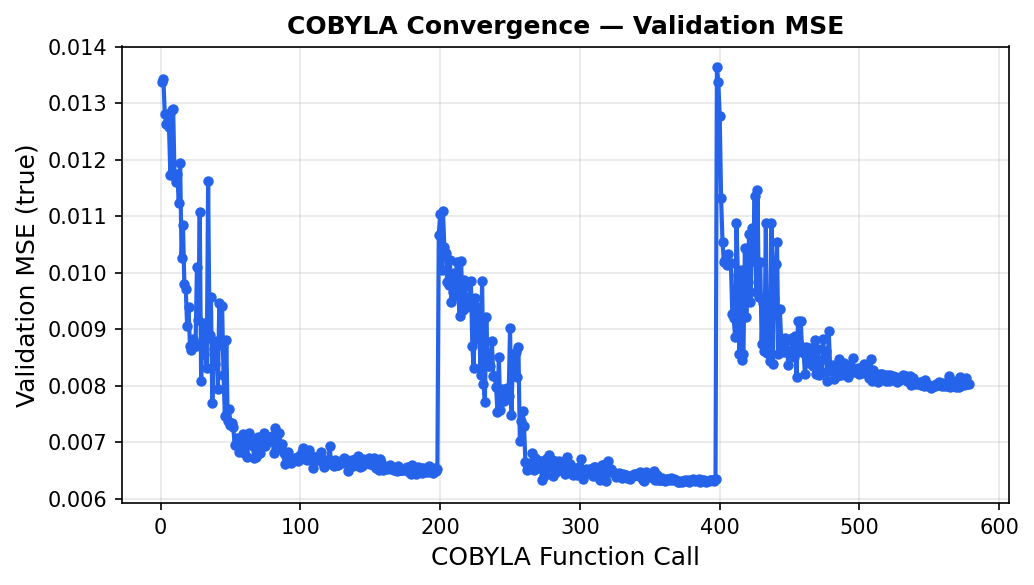

Convergence saved to cache_quantum_RF_gdsc_5000/figures/fig1_cobyla_convergence.png


In [ ]:
# ── Cell 7 : DE Convergence Plot ──────────────────────────────────────────────
conv_file = os.path.join(CACHE_DIR, 'cobyla_convergence.npy')
if os.path.exists(conv_file):
    history = np.load(conv_file)
    fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
    ax.plot(history[:, 0], history[:, 1],
            color='#2563EB', linewidth=2, marker='o', markersize=4)
    ax.set_xlabel('COBYLA Function Call', fontsize=12)
    ax.set_ylabel('Validation MSE (true)', fontsize=12)
    ax.set_title('COBYLA Convergence — Validation MSE', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, 'fig1_cobyla_convergence.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Convergence saved to {FIGDIR}/fig1_cobyla_convergence.png')
else:
    print('No convergence history found (weights loaded from cache).')

In [ ]:
# ── Cell 8 : Quantum Feature Computation ─────────────────────────────────────
if (os.path.exists(X_TRAIN_Q_FILE)
        and os.path.exists(X_VAL_Q_FILE)
        and os.path.exists(X_TEST_Q_FILE)):
    print('Loading quantum features from cache...')
    X_train_q = np.load(X_TRAIN_Q_FILE)
    X_val_q   = np.load(X_VAL_Q_FILE)
    X_test_q  = np.load(X_TEST_Q_FILE)
else:
    print('Computing quantum features (train)...')
    X_train_q = quantum_feature_map(X_train, best_weights, circuit_default, verbose=True)
    np.save(X_TRAIN_Q_FILE, X_train_q)

    print('Computing quantum features (val)...')
    X_val_q = quantum_feature_map(X_val, best_weights, circuit_default, verbose=True)
    np.save(X_VAL_Q_FILE, X_val_q)

    print('Computing quantum features (test)...')
    X_test_q = quantum_feature_map(X_test, best_weights, circuit_default, verbose=True)
    np.save(X_TEST_Q_FILE, X_test_q)

print(f'Shapes — train_q: {X_train_q.shape}  val_q: {X_val_q.shape}  test_q: {X_test_q.shape}')
print(f'Value range — min: {X_train_q.min():.4f}  max: {X_train_q.max():.4f}  '
      f'(expected in [-1, 1] as PauliZ expectation values)')

Computing quantum features (train)...
  Feature map: 917/9174 samples
  Feature map: 1834/9174 samples
  Feature map: 2751/9174 samples
  Feature map: 3668/9174 samples
  Feature map: 4585/9174 samples
  Feature map: 5502/9174 samples
  Feature map: 6419/9174 samples
  Feature map: 7336/9174 samples
  Feature map: 8253/9174 samples
  Feature map: 9170/9174 samples
Computing quantum features (val)...
  Feature map: 196/1966 samples
  Feature map: 392/1966 samples
  Feature map: 588/1966 samples
  Feature map: 784/1966 samples
  Feature map: 980/1966 samples
  Feature map: 1176/1966 samples
  Feature map: 1372/1966 samples
  Feature map: 1568/1966 samples
  Feature map: 1764/1966 samples
  Feature map: 1960/1966 samples
Computing quantum features (test)...
  Feature map: 196/1966 samples
  Feature map: 392/1966 samples
  Feature map: 588/1966 samples
  Feature map: 784/1966 samples
  Feature map: 980/1966 samples
  Feature map: 1176/1966 samples
  Feature map: 1372/1966 samples
  Feature

In [ ]:
# ── Cell 9 : Model Training — RF Classical & RF Hybrid ───────────────────────
#
# DESIGN: one RF classical (raw features) vs one RF hybrid (quantum features).
# Both use IDENTICAL RandomizedSearchCV setup (same param_dist, n_iter, cv, seed)
# to ensure a perfectly symmetric, fair comparison.


RF_PARAM_DIST = {
    'n_estimators':      [50, 100, 200, 300],
    'max_depth':         [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', None]
}


def tune_rf(X_tr, Y_tr, label='', n_iter=20):
    """RandomizedSearchCV on RF — identical setup for classical and hybrid."""
    print(f'  Tuning {label}  ({n_iter} iter, {N_SPLITS_CV}-fold CV)...')
    rf = RandomForestRegressor(random_state=SEED, n_jobs=-1)
    search = RandomizedSearchCV(
        rf, RF_PARAM_DIST,
        n_iter=n_iter,
        scoring='neg_mean_squared_error',
        cv=N_SPLITS_CV,
        random_state=SEED,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_tr, Y_tr)
    print(f'  Best params: {search.best_params_}')
    print(f'  Best CV MSE: {-search.best_score_:.6f}')
    return search.best_estimator_


print('\n── Classical RF ──')
if os.path.exists(MODEL_CLASSICAL_FILE):
    rf_classical = load(MODEL_CLASSICAL_FILE)
    print('  Loaded from cache.')
else:
    rf_classical = tune_rf(X_train, Y_train, label='Classical RF')
    dump(rf_classical, MODEL_CLASSICAL_FILE)

print('\n── Hybrid RF (quantum features) ──')
if os.path.exists(MODEL_HYBRID_FILE):
    rf_hybrid = load(MODEL_HYBRID_FILE)
    print('  Loaded from cache.')
else:
    rf_hybrid = tune_rf(X_train_q, Y_train, label='Hybrid RF')
    dump(rf_hybrid, MODEL_HYBRID_FILE)

print('\nBoth models trained.')


── Classical RF ──
  Tuning Classical RF  (20 iter, 5-fold CV)...
  Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
  Best CV MSE: 0.001893

── Hybrid RF (quantum features) ──
  Tuning Hybrid RF  (20 iter, 5-fold CV)...
  Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}
  Best CV MSE: 0.006345

Both models trained.


In [ ]:
# ── Cell 10 : 5-Fold Cross-Validation ────────────────────────────────────────
#
# CV is performed on (X_train ∪ X_val) — X_test remains untouched.
# For the hybrid model, precomputed quantum features (X_trainval_q)
# are used with the same fold indices — no new circuit calls needed.
#
# NOTE best_weights were optimized on X_train
#

X_trainval   = np.vstack([X_train,   X_val])
X_trainval_q = np.vstack([X_train_q, X_val_q])
Y_trainval   = np.concatenate([Y_train, Y_val])

kf = KFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=SEED)
cv_scores = {'classical': [], 'hybrid': []}

print(f'Running {N_SPLITS_CV}-Fold CV on X_trainval ({len(Y_trainval)} samples)...')

for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_trainval)):
    # ── Classical RF ─────────────────────────────────────────────────────────
    rf_c = RandomForestRegressor(**rf_classical.get_params())
    rf_c.fit(X_trainval[tr_idx], Y_trainval[tr_idx])
    pred_c = rf_c.predict(X_trainval[vl_idx])
    cv_scores['classical'].append({
        'mse':      mean_squared_error(Y_trainval[vl_idx], pred_c),
        'mae':      mean_absolute_error(Y_trainval[vl_idx], pred_c),
        'r2':       r2_score(Y_trainval[vl_idx], pred_c),
        'pearson':  pearsonr(Y_trainval[vl_idx], pred_c)[0],
        'spearman': spearmanr(Y_trainval[vl_idx], pred_c)[0]
    })

    # ── Hybrid RF (precomputed quantum features, same fold indices) ───────────
    rf_h = RandomForestRegressor(**rf_hybrid.get_params())
    rf_h.fit(X_trainval_q[tr_idx], Y_trainval[tr_idx])
    pred_h = rf_h.predict(X_trainval_q[vl_idx])
    cv_scores['hybrid'].append({
        'mse':      mean_squared_error(Y_trainval[vl_idx], pred_h),
        'mae':      mean_absolute_error(Y_trainval[vl_idx], pred_h),
        'r2':       r2_score(Y_trainval[vl_idx], pred_h),
        'pearson':  pearsonr(Y_trainval[vl_idx], pred_h)[0],
        'spearman': spearmanr(Y_trainval[vl_idx], pred_h)[0]
    })

    print(f'  Fold {fold+1}/{N_SPLITS_CV}  '
          f'Classical R²={cv_scores["classical"][-1]["r2"]:.4f}  '
          f'Hybrid R²={cv_scores["hybrid"][-1]["r2"]:.4f}')


def cv_summary(scores, label):
    keys = ['mse', 'mae', 'r2', 'pearson', 'spearman']
    return pd.Series(
        {k: f"{np.mean([s[k] for s in scores]):.4f} ± {np.std([s[k] for s in scores]):.4f}"
         for k in keys},
        name=label
    )

cv_df = pd.DataFrame([
    cv_summary(cv_scores['classical'], 'Classical RF'),
    cv_summary(cv_scores['hybrid'],    'Hybrid RF (quantum)')
])

print(f'\n── {N_SPLITS_CV}-Fold CV Results (mean ± std) ──')
print(cv_df.to_string())

Running 5-Fold CV on X_trainval (11140 samples)...
  Fold 1/5  Classical R²=0.9052  Hybrid R²=0.6595
  Fold 2/5  Classical R²=0.9234  Hybrid R²=0.6510
  Fold 3/5  Classical R²=0.8782  Hybrid R²=0.6356
  Fold 4/5  Classical R²=0.9044  Hybrid R²=0.6505
  Fold 5/5  Classical R²=0.9072  Hybrid R²=0.6807

── 5-Fold CV Results (mean ± std) ──
                                 mse              mae               r2          pearson         spearman
Classical RF         0.0017 ± 0.0002  0.0251 ± 0.0008  0.9037 ± 0.0145  0.9513 ± 0.0076  0.9459 ± 0.0062
Hybrid RF (quantum)  0.0061 ± 0.0003  0.0531 ± 0.0006  0.6555 ± 0.0148  0.8119 ± 0.0100  0.8166 ± 0.0117


In [ ]:
# ── Cell 11 : Wilcoxon Signed-Rank Test ───────────────────────────────────────

r2_c  = [s['r2']  for s in cv_scores['classical']]
r2_h  = [s['r2']  for s in cv_scores['hybrid']]
mse_c = [s['mse'] for s in cv_scores['classical']]
mse_h = [s['mse'] for s in cv_scores['hybrid']]

stat_r2,  p_r2  = wilcoxon(r2_h, r2_c,   alternative='greater')
stat_mse, p_mse = wilcoxon(mse_c, mse_h, alternative='greater')

print('── Wilcoxon Signed-Rank Test (one-sided: hybrid > classical) ──')
print(f'  R²  stat={stat_r2:.3f}   p={p_r2:.4f}   '
      f'{"significant (p<0.05)" if p_r2  < 0.05 else "not significant (p>=0.05)"}')
print(f'  MSE stat={stat_mse:.3f}  p={p_mse:.4f}   '
      f'{"significant (p<0.05)" if p_mse < 0.05 else "not significant (p>=0.05)"}')
print('\nNote: with N=5 folds, Wilcoxon has limited power. Report exact p-values in the paper.')

── Wilcoxon Signed-Rank Test (one-sided: hybrid > classical) ──
  R²  stat=0.000   p=1.0000   not significant (p>=0.05)
  MSE stat=0.000  p=1.0000   not significant (p>=0.05)

Note: with N=5 folds, Wilcoxon has limited power. Report exact p-values in the paper.


In [ ]:
# ── Cell 12 : Final Holdout Evaluation — X_test touched ONCE ─────────────────

def evaluate(model, X_te, Y_te, label):
    tracemalloc.start()
    t0     = time.time()
    Y_pred = model.predict(X_te)
    elapsed = time.time() - t0
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    pr, _ = pearsonr(Y_te, Y_pred)
    sr, _ = spearmanr(Y_te, Y_pred)

    return {
        'Model':        label,
        'MSE':          mean_squared_error(Y_te, Y_pred),
        'RMSE':         np.sqrt(mean_squared_error(Y_te, Y_pred)),
        'MAE':          mean_absolute_error(Y_te, Y_pred),
        'R2':           r2_score(Y_te, Y_pred),
        'Pearson r':    pr,
        'Spearman rho': sr,
        'Time (s)':     elapsed,
        'Memory (MB)':  peak / 1024**2,
        '_pred':        Y_pred
    }

print('Final evaluation on X_test:')
res_classical = evaluate(rf_classical, X_test,   Y_test, 'Classical RF')
res_hybrid    = evaluate(rf_hybrid,    X_test_q, Y_test, 'Hybrid RF (quantum)')

preds = {
    'Classical RF':        res_classical.pop('_pred'),
    'Hybrid RF (quantum)': res_hybrid.pop('_pred')
}

results_df = pd.DataFrame([res_classical, res_hybrid]).set_index('Model')
display_cols = ['MSE', 'RMSE', 'MAE', 'R2', 'Pearson r', 'Spearman rho', 'Time (s)', 'Memory (MB)']

print('\n── Test Set Results ──')
print(results_df[display_cols].round(4).to_string())

Final evaluation on X_test:

── Test Set Results ──
                        MSE    RMSE     MAE      R2  Pearson r  Spearman rho  Time (s)  Memory (MB)
Model                                                                                              
Classical RF         0.0016  0.0406  0.0253  0.9138     0.9564        0.9436    0.3417       0.3978
Hybrid RF (quantum)  0.0062  0.0791  0.0544  0.6732     0.8244        0.8251    0.2020       0.3777


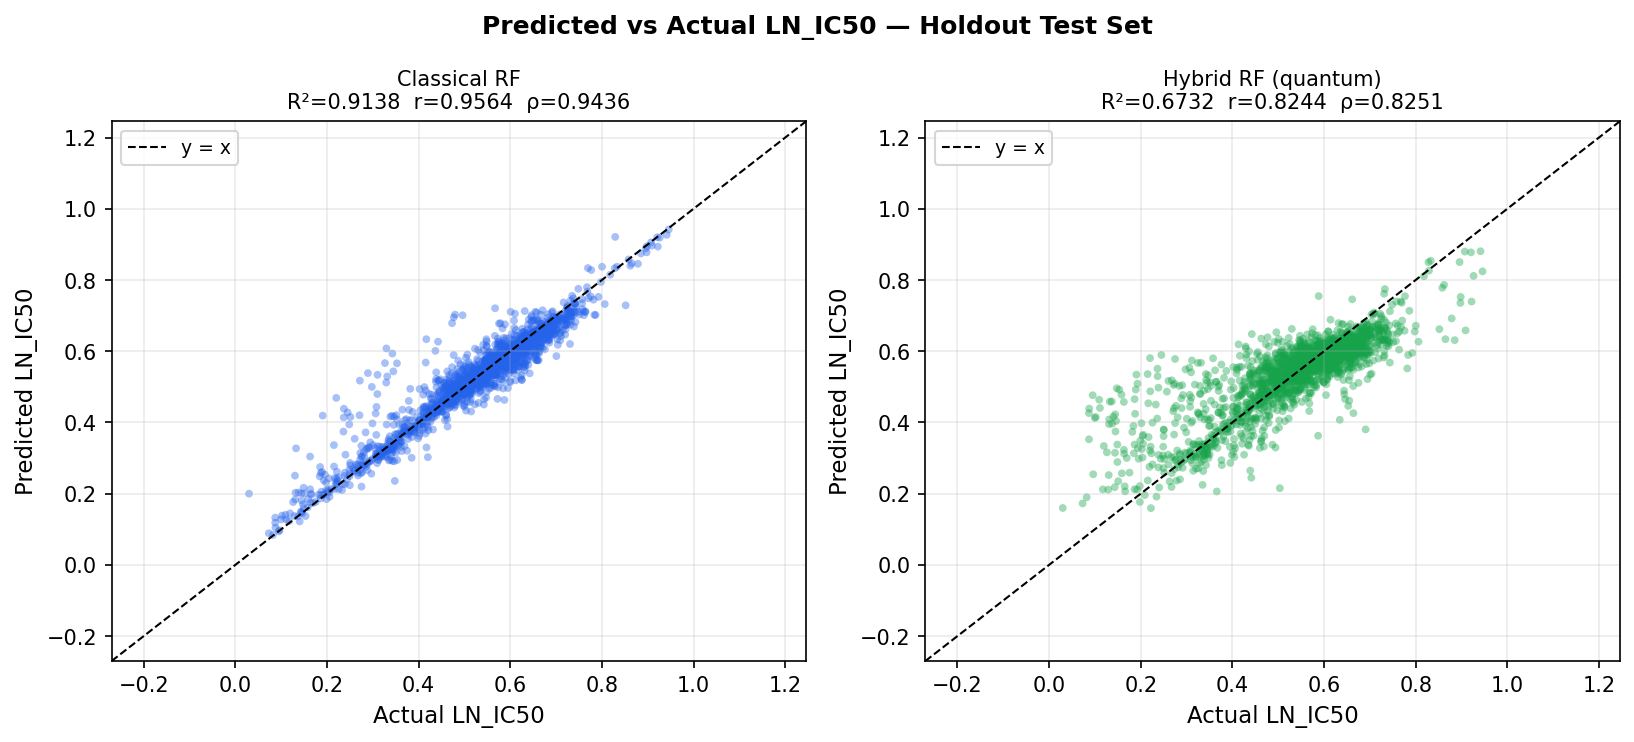

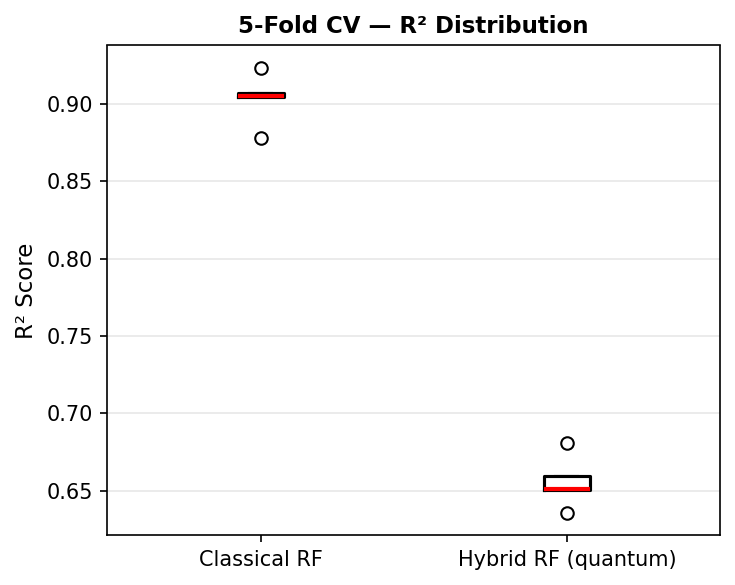

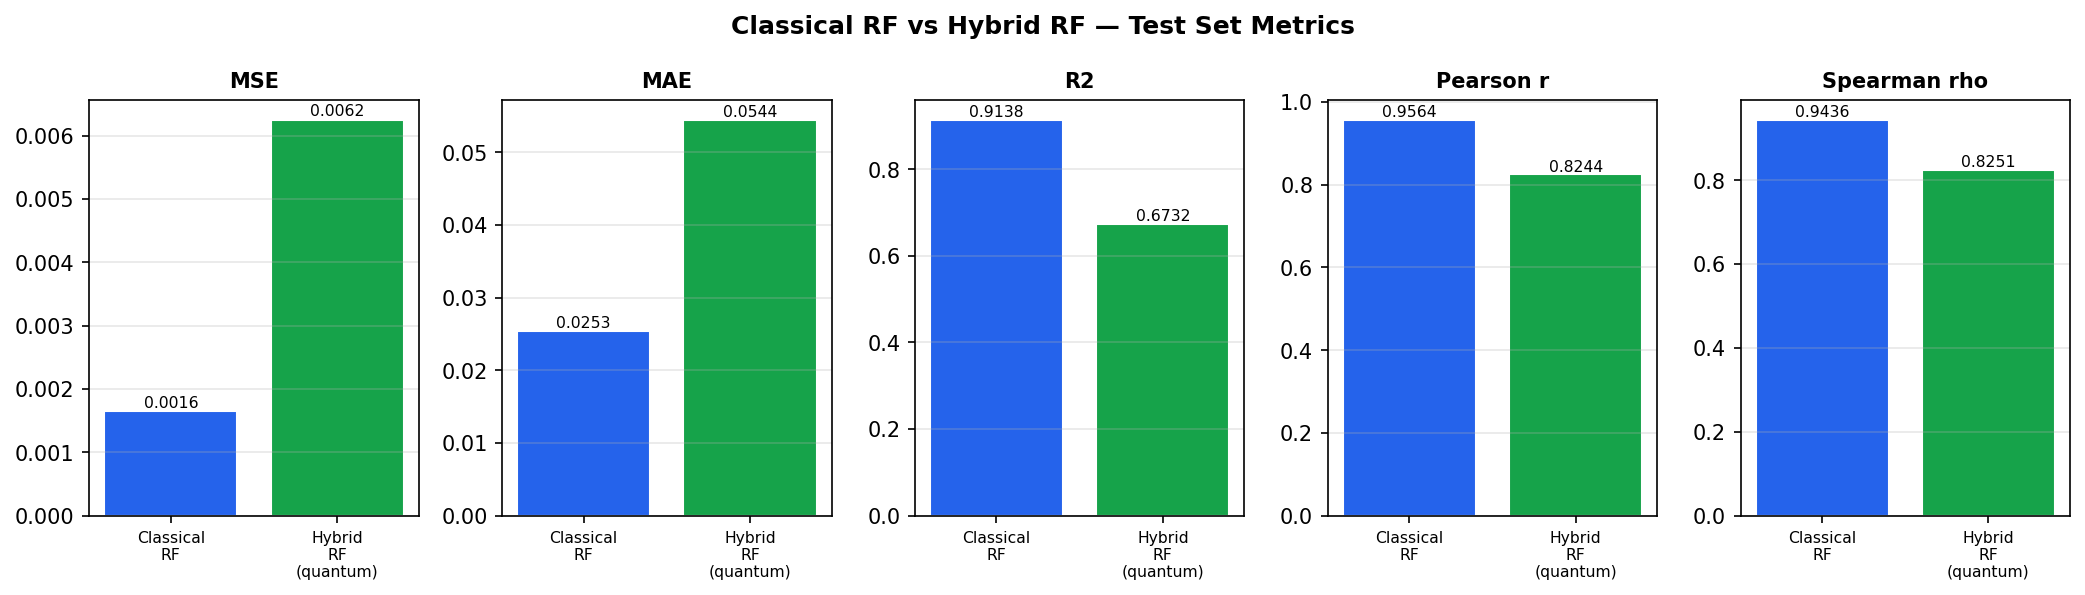

Figures saved to /home/host1-vm4/cache_quantum_RF_gdsc_5000/figures


In [ ]:
# ── Cell 13 : Publication Figures ─────────────────────────────────────────────

PALETTE = {'Classical RF': '#2563EB', 'Hybrid RF (quantum)': '#16A34A'}

# ── Figure 2: Predicted vs Actual scatter ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 5), dpi=150)
for ax, (label, color) in zip(axes, PALETTE.items()):
    y_pred = preds[label]
    lims = [min(Y_test.min(), y_pred.min()) - 0.3,
            max(Y_test.max(), y_pred.max()) + 0.3]
    ax.scatter(Y_test, y_pred, alpha=0.4, s=14, color=color, edgecolors='none')
    ax.plot(lims, lims, 'k--', linewidth=1, label='y = x')
    ax.set_xlim(lims); ax.set_ylim(lims)
    r2v = results_df.loc[label, 'R2']
    prv = results_df.loc[label, 'Pearson r']
    srv = results_df.loc[label, 'Spearman rho']
    ax.set_title(f'{label}\nR²={r2v:.4f}  r={prv:.4f}  ρ={srv:.4f}', fontsize=10)
    ax.set_xlabel('Actual LN_IC50', fontsize=11)
    ax.set_ylabel('Predicted LN_IC50', fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.suptitle('Predicted vs Actual LN_IC50 — Holdout Test Set', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig2_pred_vs_actual.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 3: CV boxplot ───────────────────────────────────────────────────────
cv_plot_df = pd.DataFrame({
    'Classical RF':        [s['r2'] for s in cv_scores['classical']],
    'Hybrid RF (quantum)': [s['r2'] for s in cv_scores['hybrid']]
})
fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
cv_plot_df.boxplot(ax=ax, grid=False,
                   medianprops=dict(color='red', linewidth=2),
                   boxprops=dict(linewidth=1.5))
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title(f'{N_SPLITS_CV}-Fold CV — R² Distribution', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig3_cv_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 4: Metric comparison bar chart ─────────────────────────────────────
metrics_bar = ['MSE', 'MAE', 'R2', 'Pearson r', 'Spearman rho']
fig, axes = plt.subplots(1, len(metrics_bar), figsize=(14, 4), dpi=150)
colors = list(PALETTE.values())
labels = list(PALETTE.keys())

for ax, metric in zip(axes, metrics_bar):
    vals = [results_df.loc[l, metric] for l in labels]
    bars = ax.bar(range(len(labels)), vals, color=colors, edgecolor='white')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels([l.replace(' ', '\n') for l in labels], fontsize=7.5)
    ax.set_title(metric, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003 * abs(max(vals) - min(vals)),
                f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('Classical RF vs Hybrid RF — Test Set Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'fig4_metrics_bar.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'Figures saved to {os.path.abspath(FIGDIR)}')